In [1]:
import jax
jax.config.update("jax_enable_x64", True)
from fewjaxstudy.trajectory.ode import solve_dynamics
import jax.numpy as jnp

from few.utils.constants import YRSID_SI, MTSUN_SI


In [2]:
m1 = 1e5
m2 = 1e1
a = 0.7
p0 = 10.0
e0 = 0.5
T = 1

M = m1 + m2
Msec = M * MTSUN_SI
mu = m1 * m2 / M
nu = mu / M
T_in = T * YRSID_SI / Msec * nu

sol = solve_dynamics(m1, m2, a, p0, e0, T)

In [34]:
solve_dynamics_jit = jax.jit(solve_dynamics)
solve_many_dynamics = jax.vmap(solve_dynamics_jit, in_axes=(None, None, None, 0, None, None), out_axes=0)
_ = solve_dynamics_jit(m1, m2, a, p0, e0, T)

In [36]:
ps = jnp.linspace(10.0, 11.0, 10)
many = solve_many_dynamics(m1, m2, a, ps, e0, T)

In [38]:
jax.vmap(lambda s: s.evaluate(10.09))(many)

Array([[ 9.8947055 ,  0.49231444,  0.22258141,  0.16597945],
       [10.00948145,  0.49266497,  0.21863697,  0.16365409],
       [10.12408331,  0.49299539,  0.21481281,  0.16138243],
       [10.2385217 ,  0.4933071 ,  0.21110356,  0.15916273],
       [10.35280647,  0.49360137,  0.20750416,  0.15699332],
       [10.4669467 ,  0.49387938,  0.20400986,  0.1548726 ],
       [10.58095082,  0.49414222,  0.20061619,  0.15279903],
       [10.69482668,  0.4943909 ,  0.19731893,  0.15077114],
       [10.80858153,  0.49462633,  0.1941141 ,  0.14878753],
       [10.92222214,  0.49484936,  0.19099794,  0.14684684]],      dtype=float64)

In [13]:
# %timeit solve_many_dynamics(m1s, m2, a, p0, e0, T)

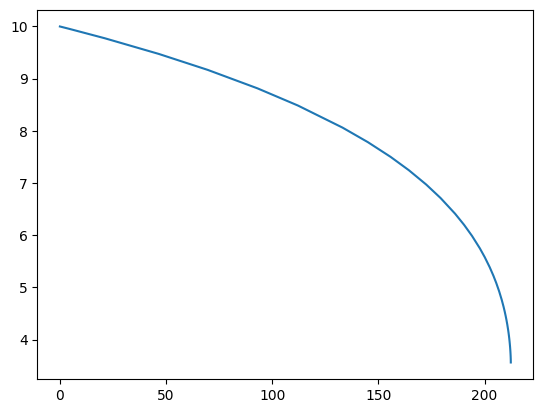

In [6]:
import matplotlib.pyplot as plt

plt.plot(sol.ts, sol.ys[:, 0])